# 4.4 Systematic Error Decomposition (H3)

**Hypothesis H3:** Misclassification errors are not random — they reflect methodological structure (hemisphere symmetry, spatial proximity) and a residual functional reorganization signal.

**Analysis pipeline:**
1. Baseline error breakdown by hemisphere × network
2. Sankey chart of error flow
3. Load hemisphere-specific model results (already trained)
4. Spatial proximity filtering using MNI coordinates
5. Waterfall chart of sequential error reduction
6. Summary tables

**Key files:**
- `full_connectivity_analysis/task_testing_one_vs_rest/task_predictions.npy`
- `full_connectivity_analysis/task_testing_one_vs_rest/task_true_labels.npy`
- `full_connectivity_analysis/task_testing_one_vs_rest/task_confusion_matrix.npy`
- `hemisphere_analysis/left_hemisphere/task_testing_one_vs_rest/task_predictions.npy`
- `hemisphere_analysis/right_hemisphere/task_testing_one_vs_rest/task_predictions.npy`
- `network_files/Schaefer2018_200Parcels_Tian_32Parcels.csv`

## Cell 1 — Imports and Path Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
from pathlib import Path

# ---------------------------------------------------------------------------
# Paths — notebook lives at analysis/hypothesis_testing/
# ---------------------------------------------------------------------------
ROOT          = Path("../..")
FULL_TASK_DIR = ROOT / "data/results/full_connectivity_analysis/task_testing_one_vs_rest"
HEMI_DIR      = ROOT / "data/results/hemisphere_analysis"
ATLAS_FILE    = ROOT / "data/network_files/Schaefer2018_200Parcels_Tian_32Parcels.csv"

LEFT_TASK_DIR  = HEMI_DIR / "left_hemisphere/task_testing_one_vs_rest"
RIGHT_TASK_DIR = HEMI_DIR / "right_hemisphere/task_testing_one_vs_rest"

required_files = [
    FULL_TASK_DIR  / "task_predictions.npy",
    FULL_TASK_DIR  / "task_true_labels.npy",
    FULL_TASK_DIR  / "task_confusion_matrix.npy",
    FULL_TASK_DIR  / "task_testing_summary.json",
    LEFT_TASK_DIR  / "task_predictions.npy",
    LEFT_TASK_DIR  / "task_true_labels.npy",
    LEFT_TASK_DIR  / "task_testing_summary.json",
    RIGHT_TASK_DIR / "task_predictions.npy",
    RIGHT_TASK_DIR / "task_true_labels.npy",
    RIGHT_TASK_DIR / "task_testing_summary.json",
    ATLAS_FILE,
]

for f in required_files:
    status = "✓" if f.exists() else "✗ MISSING"
    print(f"{status}  {f.relative_to(ROOT)}")

✓  data/results/full_connectivity_analysis/task_testing_one_vs_rest/task_predictions.npy
✓  data/results/full_connectivity_analysis/task_testing_one_vs_rest/task_true_labels.npy
✓  data/results/full_connectivity_analysis/task_testing_one_vs_rest/task_confusion_matrix.npy
✓  data/results/full_connectivity_analysis/task_testing_one_vs_rest/task_testing_summary.json
✓  data/results/hemisphere_analysis/left_hemisphere/task_testing_one_vs_rest/task_predictions.npy
✓  data/results/hemisphere_analysis/left_hemisphere/task_testing_one_vs_rest/task_true_labels.npy
✓  data/results/hemisphere_analysis/left_hemisphere/task_testing_one_vs_rest/task_testing_summary.json
✓  data/results/hemisphere_analysis/right_hemisphere/task_testing_one_vs_rest/task_predictions.npy
✓  data/results/hemisphere_analysis/right_hemisphere/task_testing_one_vs_rest/task_true_labels.npy
✓  data/results/hemisphere_analysis/right_hemisphere/task_testing_one_vs_rest/task_testing_summary.json
✓  data/network_files/Schaefer201

## Cell 2 — Load Atlas and Build Region Metadata

In [2]:
# ---------------------------------------------------------------------------
# Atlas CSV: ROI Label (1-based), ROI Name, R, A, S (MNI coordinates)
# We convert ROI Label to 0-based index (region_idx = ROI Label - 1)
# Subcortical regions: ROI Labels 201–232 → region_idx 200–231
# ---------------------------------------------------------------------------
atlas_df = pd.read_csv(ATLAS_FILE)
atlas_df.columns = atlas_df.columns.str.strip()
print("Atlas columns:", atlas_df.columns.tolist())
print(f"Atlas rows   : {len(atlas_df)}")

# Rename for clarity
atlas_df = atlas_df.rename(columns={
    "ROI Label" : "roi_label",
    "ROI Name"  : "roi_name",
    "R"         : "x",
    "A"         : "y",
    "S"         : "z",
})

# Drop duplicate rows if any (atlas has a duplicate for ROI 200)
atlas_df = atlas_df.drop_duplicates(subset="roi_label").reset_index(drop=True)

# 0-based region index
atlas_df["region_idx"] = atlas_df["roi_label"] - 1

# ---------------------------------------------------------------------------
# Derive hemisphere from ROI name:
#   Cortical: contains '_LH_' → left,  '_RH_' → right
#   Subcortical: suffix '-lh' → left,  '-rh' → right
# ---------------------------------------------------------------------------
def get_hemisphere(name):
    n = str(name)
    if "_LH_" in n or n.endswith("-lh"):
        return "left"
    elif "_RH_" in n or n.endswith("-rh"):
        return "right"
    return "unknown"

atlas_df["hemisphere"] = atlas_df["roi_name"].apply(get_hemisphere)

# ---------------------------------------------------------------------------
# Derive network label:
#   Cortical format: 17Networks_LH_<Network>_<Subregion>
#     → take the 3rd token split by '_'  (e.g. 'VisCent', 'SomMotA', 'Default')
#     → map to 7 canonical network names
#   Subcortical: group all into 'Subcortical'
# ---------------------------------------------------------------------------
SUBCORTICAL_IDS = set(range(200, 232))   # region_idx 200–231

NETWORK_MAP = {
    "VisCent"      : "Visual",
    "VisPeri"      : "Visual",
    "SomMotA"      : "SomatoMotor",
    "SomMotB"      : "SomatoMotor",
    "DorsAttnA"    : "DorsalAttention",
    "DorsAttnB"    : "DorsalAttention",
    "SalVentAttnA" : "SalVentAttention",
    "SalVentAttnB" : "SalVentAttention",
    "LimbicA"      : "Limbic",
    "LimbicB"      : "Limbic",
    "ContA"        : "Control",
    "ContB"        : "Control",
    "ContC"        : "Control",
    "DefaultA"     : "Default",
    "DefaultB"     : "Default",
    "DefaultC"     : "Default",
    "TempPar"      : "TempParietal",
}

def get_network(row):
    if row["region_idx"] in SUBCORTICAL_IDS:
        return "Subcortical"
    parts = str(row["roi_name"]).split("_")
    # parts[0]='17Networks', parts[1]='LH'/'RH', parts[2]=network token
    if len(parts) >= 3:
        return NETWORK_MAP.get(parts[2], parts[2])
    return "Unknown"

atlas_df["network"] = atlas_df.apply(get_network, axis=1)

# Build lookup arrays indexed by region_idx (0–231)
n_regions   = 232
hemisphere  = atlas_df.set_index("region_idx")["hemisphere"].to_dict()
network     = atlas_df.set_index("region_idx")["network"].to_dict()
coords      = atlas_df.set_index("region_idx")[["x","y","z"]].to_dict(orient="index")

print(f"\nUnique networks  : {sorted(atlas_df['network'].unique())}")
print(f"Unique hemispheres: {sorted(atlas_df['hemisphere'].unique())}")
print(f"Subcortical count : {(atlas_df['region_idx'].isin(SUBCORTICAL_IDS)).sum()}")
atlas_df.head(3)

Atlas columns: ['ROI Label', 'ROI Name', 'R', 'A', 'S']
Atlas rows   : 233

Unique networks  : ['Control', 'Default', 'DorsalAttention', 'Limbic', 'SalVentAttention', 'SomatoMotor', 'Subcortical', 'TempParietal', 'Visual']
Unique hemispheres: ['left', 'right']
Subcortical count : 32


,roi_label,roi_name,x,y,z,region_idx,hemisphere,network
0,1,17Networks_LH_VisCent_ExStr_1,-26,-78,-14,0,left,Visual
1,2,17Networks_LH_VisCent_ExStr_2,-26,-96,-12,1,left,Visual
2,3,17Networks_LH_VisCent_Striate_1,-6,-92,-4,2,left,Visual


## Cell 3 — Load Predictions and Identify Baseline Errors

In [3]:
task_true  = np.load(FULL_TASK_DIR / "task_true_labels.npy")
task_pred  = np.load(FULL_TASK_DIR / "task_predictions.npy")

with open(FULL_TASK_DIR / "task_testing_summary.json") as f:
    task_summary = json.load(f)

N_SAMPLES   = len(task_true)
N_CLASSES   = 232
CHANCE      = 1 / N_CLASSES

error_mask   = task_pred != task_true
n_errors     = int(error_mask.sum())
baseline_acc = float(np.mean(~error_mask))

true_err  = task_true[error_mask]
pred_err  = task_pred[error_mask]

print(f"Total samples   : {N_SAMPLES:,}")
print(f"Baseline errors : {n_errors:,}")
print(f"Baseline acc    : {baseline_acc*100:.2f}%")

Total samples   : 46,400
Baseline errors : 12,511
Baseline acc    : 73.04%


## Cell 4 — Categorise Errors by Hemisphere × Network

In [4]:
# For every error: determine same/diff hemisphere and same/diff network
hemi_true = np.array([hemisphere.get(r, "unknown") for r in true_err])
hemi_pred = np.array([hemisphere.get(r, "unknown") for r in pred_err])
net_true  = np.array([network.get(r,   "unknown") for r in true_err])
net_pred  = np.array([network.get(r,   "unknown") for r in pred_err])

same_hemi = hemi_true == hemi_pred
same_net  = net_true  == net_pred

# 4 error categories
SH_SN = int(( same_hemi &  same_net).sum())   # Same Hemi, Same Network
SH_DN = int(( same_hemi & ~same_net).sum())   # Same Hemi, Diff Network
DH_SN = int((~same_hemi &  same_net).sum())   # Diff Hemi, Same Network
DH_DN = int((~same_hemi & ~same_net).sum())   # Diff Hemi, Diff Network

print(f"SH_SN: {SH_SN}, SH_DN: {SH_DN}, DH_SN: {DH_SN}, DH_DN: {DH_DN}")
print(f"Sum of categories: {SH_SN + SH_DN + DH_SN + DH_DN} (should equal {n_errors})")
print()

cross_hemi_total = DH_SN + DH_DN

# Chi-square goodness-of-fit: observed vs uniform expected
observed  = np.array([SH_SN, SH_DN, DH_SN, DH_DN])
expected  = np.full(4, n_errors / 4)
chi2_stat, chi2_p = stats.chisquare(observed, f_exp=expected)
cramers_v = np.sqrt(chi2_stat / (n_errors * (4 - 1)))

print(f"Error categories (n={n_errors:,}):")
print(f"  Same Hemi, Same Network : {SH_SN:,}  ({SH_SN/n_errors*100:.1f}%)")
print(f"  Same Hemi, Diff Network : {SH_DN:,}  ({SH_DN/n_errors*100:.1f}%)")
print(f"  Diff Hemi, Same Network : {DH_SN:,}  ({DH_SN/n_errors*100:.1f}%)")
print(f"  Diff Hemi, Diff Network : {DH_DN:,}  ({DH_DN/n_errors*100:.1f}%)")
print(f"  Cross-hemisphere total  : {cross_hemi_total:,}  ({cross_hemi_total/n_errors*100:.1f}%)")
print()
print(f"Chi-square (vs uniform): χ²(3) = {chi2_stat:.1f}, p = {chi2_p:.2e}")
print(f"Cramér's V             : {cramers_v:.3f}")

SH_SN: 3472, SH_DN: 3585, DH_SN: 3449, DH_DN: 2005
Sum of categories: 12511 (should equal 12511)

Error categories (n=12,511):
  Same Hemi, Same Network : 3,472  (27.8%)
  Same Hemi, Diff Network : 3,585  (28.7%)
  Diff Hemi, Same Network : 3,449  (27.6%)
  Diff Hemi, Diff Network : 2,005  (16.0%)
  Cross-hemisphere total  : 5,454  (43.6%)

Chi-square (vs uniform): χ²(3) = 540.8, p = 7.00e-117
Cramér's V             : 0.120


In [5]:
import numpy as np
from scipy import stats

# ============================================================================
# STEP 1: Calculate Expected Proportions Based on Brain Structure
# ============================================================================

# You need to calculate how many possible error pairs exist in each category
# For each of the 232 regions, count:
#   - How many other regions share its hemisphere + network
#   - How many share hemisphere but different network
#   - How many are in opposite hemisphere, same network
#   - How many are in opposite hemisphere, different network

def calculate_expected_proportions(full_region_info):
    """
    Calculate expected error proportions based on brain structure.
    
    Parameters:
    -----------
    full_region_info : DataFrame with columns ['region_name', 'hemisphere', 'network']
    
    Returns:
    --------
    dict : Expected proportions for each error category
    """
    n_regions = len(full_region_info)
    
    # Count possible error targets for each region
    total_same_h_same_n = 0
    total_same_h_diff_n = 0
    total_diff_h_same_n = 0
    total_diff_h_diff_n = 0
    
    for idx, row in full_region_info.iterrows():
        true_hemi = row['hemisphere']
        true_net = row['network']
        
        # Count other regions in each category
        for idx2, row2 in full_region_info.iterrows():
            if idx == idx2:  # Skip self
                continue
            
            pred_hemi = row2['hemisphere']
            pred_net = row2['network']
            
            same_h = (true_hemi == pred_hemi)
            same_n = (true_net == pred_net)
            
            if same_h and same_n:
                total_same_h_same_n += 1
            elif same_h and not same_n:
                total_same_h_diff_n += 1
            elif not same_h and same_n:
                total_diff_h_same_n += 1
            else:  # not same_h and not same_n
                total_diff_h_diff_n += 1
    
    # Total possible error pairs
    total = total_same_h_same_n + total_same_h_diff_n + total_diff_h_same_n + total_diff_h_diff_n
    
    # Calculate proportions
    expected_props = {
        'same_h_same_n': total_same_h_same_n / total,
        'same_h_diff_n': total_same_h_diff_n / total,
        'diff_h_same_n': total_diff_h_same_n / total,
        'diff_h_diff_n': total_diff_h_diff_n / total
    }
    
    print("Expected proportions based on brain structure:")
    print(f"  Same H, Same N: {expected_props['same_h_same_n']*100:.1f}%")
    print(f"  Same H, Diff N: {expected_props['same_h_diff_n']*100:.1f}%")
    print(f"  Diff H, Same N: {expected_props['diff_h_same_n']*100:.1f}%")
    print(f"  Diff H, Diff N: {expected_props['diff_h_diff_n']*100:.1f}%")
    print()
    
    return expected_props


# ============================================================================
# STEP 2: Run Proper Chi-Square Test
# ============================================================================

# Calculate observed counts (your existing code)
hemi_true = np.array([hemisphere.get(r, "unknown") for r in true_err])
hemi_pred = np.array([hemisphere.get(r, "unknown") for r in pred_err])
net_true  = np.array([network.get(r,   "unknown") for r in true_err])
net_pred  = np.array([network.get(r,   "unknown") for r in pred_err])

same_hemi = hemi_true == hemi_pred
same_net  = net_true  == net_pred

SH_SN = int(( same_hemi &  same_net).sum())
SH_DN = int(( same_hemi & ~same_net).sum())
DH_SN = int((~same_hemi &  same_net).sum())
DH_DN = int((~same_hemi & ~same_net).sum())

n_errors = SH_SN + SH_DN + DH_SN + DH_DN

# Calculate expected counts based on brain structure
full_region_info = pd.read_csv('/home/sjoon/projects/brain_connectivity_classifier/data/FULL_region_info.csv')
expected_props = calculate_expected_proportions(full_region_info)  # You need this DataFrame

observed = np.array([SH_SN, SH_DN, DH_SN, DH_DN])
expected = np.array([
    n_errors * expected_props['same_h_same_n'],
    n_errors * expected_props['same_h_diff_n'],
    n_errors * expected_props['diff_h_same_n'],
    n_errors * expected_props['diff_h_diff_n']
])

# Chi-square test
chi2_stat, chi2_p = stats.chisquare(observed, f_exp=expected)
cramers_v = np.sqrt(chi2_stat / (n_errors * (4 - 1)))

print(f"OBSERVED ERROR DISTRIBUTION:")
print(f"  Same H, Same N: {SH_SN:,} ({SH_SN/n_errors*100:.1f}%)")
print(f"  Same H, Diff N: {SH_DN:,} ({SH_DN/n_errors*100:.1f}%)")
print(f"  Diff H, Same N: {DH_SN:,} ({DH_SN/n_errors*100:.1f}%)")
print(f"  Diff H, Diff N: {DH_DN:,} ({DH_DN/n_errors*100:.1f}%)")
print(f"  Cross-hemi total: {DH_SN + DH_DN:,} ({(DH_SN + DH_DN)/n_errors*100:.1f}%)")
print()

print(f"EXPECTED (based on brain structure):")
print(f"  Same H, Same N: {expected[0]:.0f} ({expected[0]/n_errors*100:.1f}%)")
print(f"  Same H, Diff N: {expected[1]:.0f} ({expected[1]/n_errors*100:.1f}%)")
print(f"  Diff H, Same N: {expected[2]:.0f} ({expected[2]/n_errors*100:.1f}%)")
print(f"  Diff H, Diff N: {expected[3]:.0f} ({expected[3]/n_errors*100:.1f}%)")
print()

print(f"Chi-square test (observed vs. structural expectation):")
print(f"  χ²(3) = {chi2_stat:.1f}, p = {chi2_p:.2e}")
print(f"  Cramér's V = {cramers_v:.3f}")
print()

# Enrichment analysis for cross-hemisphere errors
obs_cross_hemi_pct = (DH_SN + DH_DN) / n_errors * 100
exp_cross_hemi_pct = (expected[2] + expected[3]) / n_errors * 100
enrichment = obs_cross_hemi_pct / exp_cross_hemi_pct

print(f"CROSS-HEMISPHERE ENRICHMENT:")
print(f"  Observed: {obs_cross_hemi_pct:.1f}%")
print(f"  Expected: {exp_cross_hemi_pct:.1f}%")
print(f"  Enrichment: {enrichment:.2f}× ({'depleted' if enrichment < 1 else 'enriched'})")

Expected proportions based on brain structure:
  Same H, Same N: 2.2%
  Same H, Diff N: 47.5%
  Diff H, Same N: 2.4%
  Diff H, Diff N: 47.8%

OBSERVED ERROR DISTRIBUTION:
  Same H, Same N: 3,472 (27.8%)
  Same H, Diff N: 3,585 (28.7%)
  Diff H, Same N: 3,449 (27.6%)
  Diff H, Diff N: 2,005 (16.0%)
  Cross-hemi total: 5,454 (43.6%)

EXPECTED (based on brain structure):
  Same H, Same N: 280 (2.2%)
  Same H, Diff N: 5948 (47.5%)
  Diff H, Same N: 299 (2.4%)
  Diff H, Diff N: 5984 (47.8%)

Chi-square test (observed vs. structural expectation):
  χ²(3) = 73162.2, p = 0.00e+00
  Cramér's V = 1.396

CROSS-HEMISPHERE ENRICHMENT:
  Observed: 43.6%
  Expected: 50.2%
  Enrichment: 0.87× (depleted)


## Cell 5 — Table 1: Error Type Breakdown

In [6]:
table1 = pd.DataFrame([
    {"Error Type"          : "Same Hemi, Same Network",
     "Count"               : SH_SN,
     "% of Errors"         : f"{SH_SN/n_errors*100:.1f}%"},
    {"Error Type"          : "Same Hemi, Diff Network",
     "Count"               : SH_DN,
     "% of Errors"         : f"{SH_DN/n_errors*100:.1f}%"},
    {"Error Type"          : "Diff Hemi, Same Network",
     "Count"               : DH_SN,
     "% of Errors"         : f"{DH_SN/n_errors*100:.1f}%"},
    {"Error Type"          : "Diff Hemi, Diff Network",
     "Count"               : DH_DN,
     "% of Errors"         : f"{DH_DN/n_errors*100:.1f}%"},
    {"Error Type"          : "── Cross-Hemisphere Total",
     "Count"               : cross_hemi_total,
     "% of Errors"         : f"{cross_hemi_total/n_errors*100:.1f}%"},
    {"Error Type"          : "── Total Errors",
     "Count"               : n_errors,
     "% of Errors"         : "100.0%"},
]).set_index("Error Type")

table1

,Count,% of Errors
Error Type,,
"Same Hemi, Same Network",3472,27.8%
"Same Hemi, Diff Network",3585,28.7%
"Diff Hemi, Same Network",3449,27.6%
"Diff Hemi, Diff Network",2005,16.0%
── Cross-Hemisphere Total,5454,43.6%
── Total Errors,12511,100.0%


## Cell 6 — Figure: Sankey Chart of Error Flow

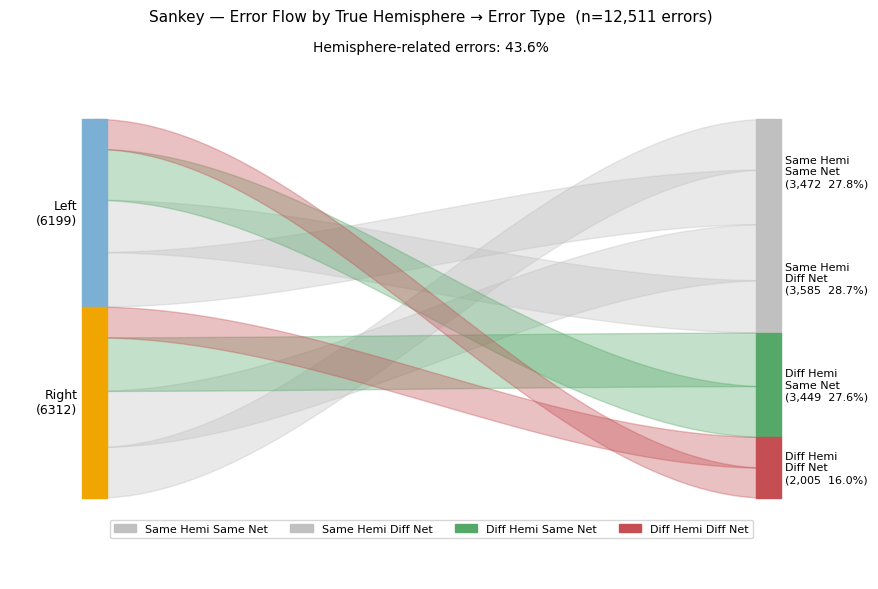

Sankey saved.


In [7]:
# ---------------------------------------------------------------------------
# Sankey using matplotlib — no plotly dependency required
# Nodes: [Left_true, Right_true] → [SH_SN, SH_DN, DH_SN, DH_DN]
# Flow is split by (true hemi) × (error category)
# ---------------------------------------------------------------------------


# Masks by true hemisphere
left_mask  = (hemi_true == "left")
right_mask = (hemi_true == "right")

# Flow counts by (true hemisphere, error type)
flows = {
    ("Left",  "SH·SN"): int(( same_hemi &  same_net & left_mask).sum()),
    ("Left",  "SH·DN"): int(( same_hemi & ~same_net & left_mask).sum()),
    ("Left",  "DH·SN"): int((~same_hemi &  same_net & left_mask).sum()),
    ("Left",  "DH·DN"): int((~same_hemi & ~same_net & left_mask).sum()),
    ("Right", "SH·SN"): int(( same_hemi &  same_net & right_mask).sum()),
    ("Right", "SH·DN"): int(( same_hemi & ~same_net & right_mask).sum()),
    ("Right", "DH·SN"): int((~same_hemi &  same_net & right_mask).sum()),
    ("Right", "DH·DN"): int((~same_hemi & ~same_net & right_mask).sum()),
}

# Base colors for the 4 error types
type_colors = {
    "SH·SN": "#4C72B0",  # Same Hemi, Same Net
    "SH·DN": "#DD8452",  # Same Hemi, Diff Net
    "DH·SN": "#55A868",  # Diff Hemi, Same Net
    "DH·DN": "#C44E52",  # Diff Hemi, Diff Net
}

# Which error types should remain highlighted (hemisphere-related)?
# Here: only the Diff Hemi categories stay colored
hemi_error_types = {"DH·SN", "DH·DN"}
gray_color = "#C0C0C0"

error_types = ["SH·SN", "SH·DN", "DH·SN", "DH·DN"]
hemi_srcs   = ["Left", "Right"]

# ---------------------------------------------------------------------------
# Set up figure
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))
ax.axis("off")

# Totals per hemisphere and overall
left_total  = sum(flows[("Left",  t)] for t in error_types)
right_total = sum(flows[("Right", t)] for t in error_types)
total_flow  = left_total + right_total

bar_height  = 0.7        # total height of the diagram
x_src, x_dst = 0.1, 0.9  # x positions in Axes coordinates

# Source bar heights and vertical positions
src_heights = {
    "Left":  left_total  / total_flow * bar_height if total_flow > 0 else 0.0,
    "Right": right_total / total_flow * bar_height if total_flow > 0 else 0.0,
}
src_y = {
    "Left":  0.15 + src_heights["Right"],  # left on top
    "Right": 0.15,
}

# Destination bar heights and positions
dst_counts = {t: flows[("Left", t)] + flows[("Right", t)] for t in error_types}
dst_heights = {
    t: (dst_counts[t] / total_flow * bar_height if total_flow > 0 else 0.0)
    for t in error_types
}

dst_y = {}
y_cur = 0.15
# Reverse order here to stack visually from bottom to top
for t in reversed(error_types):
    dst_y[t] = y_cur
    y_cur += dst_heights[t]

# ---------------------------------------------------------------------------
# Draw source bars (Left / Right hemispheres)
# ---------------------------------------------------------------------------
src_colors = {"Left": "#7BAFD4", "Right": "#F0A500"}

for h in hemi_srcs:
    ax.add_patch(plt.Rectangle(
        (x_src - 0.015, src_y[h]), 0.03, src_heights[h],
        color=src_colors[h], zorder=3, transform=ax.transAxes
    ))
    ax.text(
        x_src - 0.02,
        src_y[h] + src_heights[h] / 2,
        f"{h}\n({src_heights[h] * total_flow / bar_height:.0f})" if bar_height > 0 else f"{h}\n(0)",
        ha="right",
        va="center",
        fontsize=9,
        transform=ax.transAxes,
    )

# ---------------------------------------------------------------------------
# Draw destination bars (error types),
# with hemisphere-related ones colored, others gray
# ---------------------------------------------------------------------------
type_labels = {
    "SH·SN": "Same Hemi\nSame Net",
    "SH·DN": "Same Hemi\nDiff Net",
    "DH·SN": "Diff Hemi\nSame Net",
    "DH·DN": "Diff Hemi\nDiff Net",
}

for t in error_types:
    bar_color = type_colors[t] if t in hemi_error_types else gray_color
    ax.add_patch(plt.Rectangle(
        (x_dst - 0.015, dst_y[t]), 0.03, dst_heights[t],
        color=bar_color, zorder=3, transform=ax.transAxes
    ))
    if n_errors > 0:
        pct = dst_counts[t] / n_errors * 100
    else:
        pct = 0.0

    ax.text(
        x_dst + 0.02,
        dst_y[t] + dst_heights[t] / 2,
        f"{type_labels[t]}\n({dst_counts[t]:,}  {pct:.1f}%)",
        ha="left",
        va="center",
        fontsize=8,
        transform=ax.transAxes,
    )

# ---------------------------------------------------------------------------
# Draw flows between source bars and destination bars
# Hemisphere-related flows are colored; others are gray
# ---------------------------------------------------------------------------
src_y_cursor = {h: src_y[h] for h in hemi_srcs}

for t in error_types:
    dst_y_cursor = dst_y[t]
    for h in hemi_srcs:
        val = flows[(h, t)]
        if val == 0 or total_flow == 0:
            continue

        frac   = val / total_flow * bar_height
        y0_src = src_y_cursor[h]
        y1_src = y0_src + frac
        y0_dst = dst_y_cursor
        y1_dst = dst_y_cursor + frac

        # Smooth interpolation
        t_vals = np.linspace(0, 1, 60)
        x_vals = x_src + (x_dst - x_src) * t_vals
        # cubic Hermite-like ease-in-out
        ease   = 3 * t_vals**2 - 2 * t_vals**3
        y_top  = y0_src + (y0_dst - y0_src) * ease
        y_bot  = y1_src + (y1_dst - y1_src) * ease

        flow_color = type_colors[t] if t in hemi_error_types else gray_color

        ax.fill_between(
            x_vals, y_bot, y_top,
            color=flow_color,
            alpha=0.35,
            transform=ax.transAxes,
        )

        src_y_cursor[h] += frac
        dst_y_cursor    += frac

# ---------------------------------------------------------------------------
# Legend: highlight hemi-related types, gray others
# ---------------------------------------------------------------------------
legend_patches = []
for t in error_types:
    patch_color = type_colors[t] if t in hemi_error_types else gray_color
    legend_patches.append(
        mpatches.Patch(
            color=patch_color,
            label=type_labels[t].replace("\n", " "),
        )
    )

ax.legend(
    handles=legend_patches,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.12),
    ncol=4,
    fontsize=8,
    framealpha=0.8,
)

ax.set_title(
    f"Sankey — Error Flow by True Hemisphere → Error Type  (n={n_errors:,} errors)",
    fontsize=11,
    pad=12,
)

# add hemisphere-related percentage just below the title
hemi_err_total = dst_counts["DH·SN"] + dst_counts["DH·DN"]
hemi_err_pct   = hemi_err_total / n_errors * 100 if n_errors > 0 else 0.0

ax.text(
    0.5, 0.97,  # slightly below the main title in axes coords
    f"Hemisphere-related errors: {hemi_err_pct:.1f}%",
    ha="center",
    va="bottom",
    fontsize=10,
    transform=ax.transAxes,
)

fig_dir = Path(ROOT) / "analysis/hypothesis_testing/figures"
fig_dir.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(fig_dir / "H3_sankey_error_flow.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sankey saved.")

## Cell 7 — Load Hemisphere-Specific Model Results

In [8]:
# ---------------------------------------------------------------------------
# Left-hemisphere model: trained and tested on left regions only
# Right-hemisphere model: trained and tested on right regions only
# We combine their predictions to form the full 232-region prediction set
# ---------------------------------------------------------------------------
left_true  = np.load(LEFT_TASK_DIR  / "task_true_labels.npy")
left_pred  = np.load(LEFT_TASK_DIR  / "task_predictions.npy")
right_true = np.load(RIGHT_TASK_DIR / "task_true_labels.npy")
right_pred = np.load(RIGHT_TASK_DIR / "task_predictions.npy")

with open(LEFT_TASK_DIR  / "task_testing_summary.json") as f: left_summary  = json.load(f)
with open(RIGHT_TASK_DIR / "task_testing_summary.json") as f: right_summary = json.load(f)

left_acc  = float(np.mean(left_pred  == left_true))
right_acc = float(np.mean(right_pred == right_true))

# Combined hemisphere-specific predictions
# Concatenate left + right predictions in sample order
combined_true = np.concatenate([left_true,  right_true])
combined_pred = np.concatenate([left_pred,  right_pred])

combined_acc    = float(np.mean(combined_pred == combined_true))
combined_errors = int(np.sum(combined_pred != combined_true))
acc_gain        = combined_acc - baseline_acc
errors_removed  = n_errors - combined_errors

print(f"Left-hemisphere  accuracy : {left_acc*100:.2f}%   ({int(np.sum(left_pred!=left_true)):,} errors)")
print(f"Right-hemisphere accuracy : {right_acc*100:.2f}%   ({int(np.sum(right_pred!=right_true)):,} errors)")
print(f"Combined accuracy         : {combined_acc*100:.2f}%   ({combined_errors:,} errors)")
print(f"Accuracy gain vs baseline : +{acc_gain*100:.2f}%")
print(f"Errors removed by hemi sep: {errors_removed:,}")

Left-hemisphere  accuracy : 88.75%   (2,611 errors)
Right-hemisphere accuracy : 87.97%   (2,791 errors)
Combined accuracy         : 88.36%   (5,402 errors)
Accuracy gain vs baseline : +15.32%
Errors removed by hemi sep: 7,109


## Cell 8 — Table 2: Hemisphere Model Performances

In [9]:
table2 = pd.DataFrame([
    {"Model"              : "Full connectivity (baseline)",
     "Accuracy"           : f"{baseline_acc*100:.2f}%",
     "Errors"             : f"{n_errors:,}",
     "Notes"              : "All 232 regions"},
    {"Model"              : "Left-hemisphere only",
     "Accuracy"           : f"{left_acc*100:.2f}%",
     "Errors"             : f"{int(np.sum(left_pred!=left_true)):,}",
     "Notes"              : "Left regions only"},
    {"Model"              : "Right-hemisphere only",
     "Accuracy"           : f"{right_acc*100:.2f}%",
     "Errors"             : f"{int(np.sum(right_pred!=right_true)):,}",
     "Notes"              : "Right regions only"},
    {"Model"              : "Combined hemisphere-specific",
     "Accuracy"           : f"{combined_acc*100:.2f}%",
     "Errors"             : f"{combined_errors:,}",
     "Notes"              : f"Left + right concatenated; +{acc_gain*100:.2f}% gain"},
]).set_index("Model")

table2

,Accuracy,Errors,Notes
Model,,,
Full connectivity (baseline),73.04%,"12,511",All 232 regions
Left-hemisphere only,88.75%,"2,611",Left regions only
Right-hemisphere only,87.97%,"2,791",Right regions only
Combined hemisphere-specific,88.36%,"5,402",Left + right concatenated; +15.32% gain


## Cell 9 — Build MNI Distance Matrix and Apply Spatial Proximity Filter

In [10]:
# ===========================================================================
# STEP 1: Separate regions by hemisphere and extract coordinates
# ===========================================================================

# Get region indices for each hemisphere
left_indices = [idx for idx in range(n_regions) if hemisphere.get(idx, "unknown") == "left"]
right_indices = [idx for idx in range(n_regions) if hemisphere.get(idx, "unknown") == "right"]

n_left = len(left_indices)
n_right = len(right_indices)

print(f"Left hemisphere regions: {n_left}")
print(f"Right hemisphere regions: {n_right}")

# ===========================================================================
# STEP 2: Build separate 116×116 distance matrices
# ===========================================================================

# Extract coordinates for left hemisphere
left_coord_array = np.zeros((n_left, 3))
for i, idx in enumerate(left_indices):
    if idx in coords:
        left_coord_array[i] = [coords[idx]["x"], coords[idx]["y"], coords[idx]["z"]]

# Extract coordinates for right hemisphere  
right_coord_array = np.zeros((n_right, 3))
for i, idx in enumerate(right_indices):
    if idx in coords:
        right_coord_array[i] = [coords[idx]["x"], coords[idx]["y"], coords[idx]["z"]]

# Build distance matrices (vectorized)
diff_left = left_coord_array[:, np.newaxis, :] - left_coord_array[np.newaxis, :, :]
dist_matrix_left = np.sqrt((diff_left**2).sum(axis=2))

diff_right = right_coord_array[:, np.newaxis, :] - right_coord_array[np.newaxis, :, :]
dist_matrix_right = np.sqrt((diff_right**2).sum(axis=2))

print("\nDistance matrix shapes:")
print(f"  Left: {dist_matrix_left.shape}")
print(f"  Right: {dist_matrix_right.shape}")

print("\nDistance matrix statistics:")
print(f"  Left Hemisphere:")
print(f"    Min distance: {dist_matrix_left[dist_matrix_left>0].min():.2f}mm")
print(f"    Max distance: {dist_matrix_left.max():.2f}mm")
print(f"    Mean distance: {dist_matrix_left[dist_matrix_left>0].mean():.2f}mm")

print(f"  Right Hemisphere:")
print(f"    Min distance: {dist_matrix_right[dist_matrix_right>0].min():.2f}mm")
print(f"    Max distance: {dist_matrix_right.max():.2f}mm")
print(f"    Mean distance: {dist_matrix_right[dist_matrix_right>0].mean():.2f}mm")

# ===========================================================================
# STEP 3: Identify errors for each hemisphere
# ===========================================================================

# Left hemisphere errors
left_error_mask = left_pred != left_true
left_true_err = left_true[left_error_mask]
left_pred_err = left_pred[left_error_mask]
left_errors_n = len(left_true_err)

# Right hemisphere errors
right_error_mask = right_pred != right_true
right_true_err = right_true[right_error_mask]
right_pred_err = right_pred[right_error_mask]
right_errors_n = len(right_true_err)

print(f"\nError counts:")
print(f"  Left hemisphere:  {left_errors_n:,} errors")
print(f"  Right hemisphere: {right_errors_n:,} errors")
print(f"  Combined:         {left_errors_n + right_errors_n:,} errors")

# ===========================================================================
# STEP 5: Calculate distances for errors
# ===========================================================================

PROXIMITY_THRESHOLD_MM = 20

# LEFT HEMISPHERE: Calculate distances
left_error_dists = np.array([
    dist_matrix_left[true_idx, pred_idx] 
    for true_idx, pred_idx in zip(left_true_err, left_pred_err)
])

# Identify nearby vs distal (left)
left_nearby_mask = left_error_dists < PROXIMITY_THRESHOLD_MM
left_nearby = int(left_nearby_mask.sum())
left_distal = left_errors_n - left_nearby

# RIGHT HEMISPHERE: Calculate distances
right_error_dists = np.array([
    dist_matrix_right[true_idx, pred_idx] 
    for true_idx, pred_idx in zip(right_true_err, right_pred_err)
])

# Identify nearby vs distal (right)
right_nearby_mask = right_error_dists < PROXIMITY_THRESHOLD_MM
right_nearby = int(right_nearby_mask.sum())
right_distal = right_errors_n - right_nearby

# COMBINED statistics
combined_error_dists = np.concatenate([left_error_dists, right_error_dists])
combined_errors_n = left_errors_n + right_errors_n
combined_nearby = left_nearby + right_nearby
combined_distal = left_distal + right_distal

# ===========================================================================
# STEP 6: Display results
# ===========================================================================

print("\n" + "="*70)
print("SPATIAL PROXIMITY ANALYSIS (20mm THRESHOLD)")
print("="*70)

print(f"\nLeft Hemisphere:")
print(f"  Total errors:     {left_errors_n:,}")
print(f"  Nearby (<20mm):   {left_nearby:,} ({left_nearby/left_errors_n*100:.2f}%)")
print(f"  Distal (≥20mm):   {left_distal:,} ({left_distal/left_errors_n*100:.2f}%)")

print(f"\nRight Hemisphere:")
print(f"  Total errors:     {right_errors_n:,}")
print(f"  Nearby (<20mm):   {right_nearby:,} ({right_nearby/right_errors_n*100:.2f}%)")
print(f"  Distal (≥20mm):   {right_distal:,} ({right_distal/right_errors_n*100:.2f}%)")

print(f"\nCombined:")
print(f"  Total errors:     {combined_errors_n:,}")
print(f"  Nearby (<20mm):   {combined_nearby:,} ({combined_nearby/combined_errors_n*100:.2f}%)")
print(f"  Distal (≥20mm):   {combined_distal:,} ({combined_distal/combined_errors_n*100:.2f}%)")

# ===========================================================================
# STEP 7: Distance statistics
# ===========================================================================

print(f"\nDistance Statistics:")

print(f"\n  Left Hemisphere:")
print(f"    Mean:   {left_error_dists.mean():.1f} mm")
print(f"    Median: {np.median(left_error_dists):.1f} mm")
print(f"    Min:    {left_error_dists.min():.1f} mm")
print(f"    Max:    {left_error_dists.max():.1f} mm")

print(f"\n  Right Hemisphere:")
print(f"    Mean:   {right_error_dists.mean():.1f} mm")
print(f"    Median: {np.median(right_error_dists):.1f} mm")
print(f"    Min:    {right_error_dists.min():.1f} mm")
print(f"    Max:    {right_error_dists.max():.1f} mm")

print(f"\n  Combined:")
print(f"    Mean:   {combined_error_dists.mean():.1f} mm")
print(f"    Median: {np.median(combined_error_dists):.1f} mm")
print(f"    Min:    {combined_error_dists.min():.1f} mm")
print(f"    Max:    {combined_error_dists.max():.1f} mm")

# ===========================================================================
# STEP 8: Calculate distance distribution bins
# ===========================================================================

def calculate_distance_bins(distances, bins=[0, 10, 20, 30, 50, 100, 200]):
    """Calculate histogram counts for distance bins."""
    if len(distances) == 0:
        return [0] * (len(bins) - 1)
    counts, _ = np.histogram(distances, bins=bins)
    return counts.tolist()

bins = [0, 10, 20, 30, 50, 100, 200]
bin_labels = ['0-10mm', '10-20mm', '20-30mm', '30-50mm', '50-100mm', '100-200mm']

left_bin_counts = calculate_distance_bins(left_error_dists, bins)
right_bin_counts = calculate_distance_bins(right_error_dists, bins)
combined_bin_counts = calculate_distance_bins(combined_error_dists, bins)

print("\n" + "="*70)
print("DISTANCE DISTRIBUTION BY BIN")
print("="*70)

print("\nLeft Hemisphere:")
for label, count in zip(bin_labels, left_bin_counts):
    pct = count / left_errors_n * 100 if left_errors_n > 0 else 0
    print(f"  {label:12s}: {count:4d} ({pct:5.1f}%)")
print(f"  {'TOTAL':12s}: {sum(left_bin_counts):4d} ({sum(left_bin_counts)/left_errors_n*100:5.1f}%)")

print("\nRight Hemisphere:")
for label, count in zip(bin_labels, right_bin_counts):
    pct = count / right_errors_n * 100 if right_errors_n > 0 else 0
    print(f"  {label:12s}: {count:4d} ({pct:5.1f}%)")
print(f"  {'TOTAL':12s}: {sum(right_bin_counts):4d} ({sum(right_bin_counts)/right_errors_n*100:5.1f}%)")

print("\nCombined:")
for label, count in zip(bin_labels, combined_bin_counts):
    pct = count / combined_errors_n * 100 if combined_errors_n > 0 else 0
    print(f"  {label:12s}: {count:4d} ({pct:5.1f}%)")
print(f"  {'TOTAL':12s}: {sum(combined_bin_counts):4d} ({sum(combined_bin_counts)/combined_errors_n*100:5.1f}%)")

# ===========================================================================
# STEP 9: Verification
# ===========================================================================

print("\n" + "="*70)
print("VERIFICATION")
print("="*70)

left_under_20 = sum(left_bin_counts[:2])
right_under_20 = sum(right_bin_counts[:2])
combined_under_20 = sum(combined_bin_counts[:2])

print(f"Left <20mm:     {left_under_20:,} (expected: {left_nearby:,}) {'✓' if left_under_20 == left_nearby else '✗'}")
print(f"Right <20mm:    {right_under_20:,} (expected: {right_nearby:,}) {'✓' if right_under_20 == right_nearby else '✗'}")
print(f"Combined <20mm: {combined_under_20:,} (expected: {combined_nearby:,}) {'✓' if combined_under_20 == combined_nearby else '✗'}")

print(f"\nLeft total:     {sum(left_bin_counts):,} (expected: {left_errors_n:,}) {'✓' if sum(left_bin_counts) == left_errors_n else '✗'}")
print(f"Right total:    {sum(right_bin_counts):,} (expected: {right_errors_n:,}) {'✓' if sum(right_bin_counts) == right_errors_n else '✗'}")
print(f"Combined total: {sum(combined_bin_counts):,} (expected: {combined_errors_n:,}) {'✓' if sum(combined_bin_counts) == combined_errors_n else '✗'}")

# ===========================================================================
# STEP 10: Export data for plotting
# ===========================================================================

print("\n" + "="*70)
print("📊 COPY THESE VALUES TO YOUR PLOTTING CODE")
print("="*70)

print(f"""
# Distance distribution data (VERIFIED - use in plots)
left_total = {left_errors_n}
right_total = {right_errors_n}
combined_total = {combined_errors_n}

left_counts = {left_bin_counts}
right_counts = {right_bin_counts}
combined_counts = {combined_bin_counts}

# Statistics
stats_data = {{
    'Left': {{'mean': {left_error_dists.mean():.1f}, 'median': {np.median(left_error_dists):.1f}, 'min': {left_error_dists.min():.1f}, 'max': {left_error_dists.max():.1f}}},
    'Right': {{'mean': {right_error_dists.mean():.1f}, 'median': {np.median(right_error_dists):.1f}, 'min': {right_error_dists.min():.1f}, 'max': {right_error_dists.max():.1f}}},
    'Combined': {{'mean': {combined_error_dists.mean():.1f}, 'median': {np.median(combined_error_dists):.1f}, 'min': {combined_error_dists.min():.1f}, 'max': {combined_error_dists.max():.1f}}}
}}

# Verify totals
assert sum(left_counts) == {left_errors_n}, "Left counts mismatch"
assert sum(right_counts) == {right_errors_n}, "Right counts mismatch"
assert left_counts[0] + left_counts[1] == {left_nearby}, "Left <20mm mismatch"
assert right_counts[0] + right_counts[1] == {right_nearby}, "Right <20mm mismatch"

print("Data ready for plotting! ")
""")

Left hemisphere regions: 116
Right hemisphere regions: 116

Distance matrix shapes:
  Left: (116, 116)
  Right: (116, 116)

Distance matrix statistics:
  Left Hemisphere:
    Min distance: 8.25mm
    Max distance: 160.76mm
    Mean distance: 66.09mm
  Right Hemisphere:
    Min distance: 7.21mm
    Max distance: 158.86mm
    Mean distance: 64.95mm

Error counts:
  Left hemisphere:  2,611 errors
  Right hemisphere: 2,791 errors
  Combined:         5,402 errors

SPATIAL PROXIMITY ANALYSIS (20mm THRESHOLD)

Left Hemisphere:
  Total errors:     2,611
  Nearby (<20mm):   255 (9.77%)
  Distal (≥20mm):   2,356 (90.23%)

Right Hemisphere:
  Total errors:     2,791
  Nearby (<20mm):   277 (9.92%)
  Distal (≥20mm):   2,514 (90.08%)

Combined:
  Total errors:     5,402
  Nearby (<20mm):   532 (9.85%)
  Distal (≥20mm):   4,870 (90.15%)

Distance Statistics:

  Left Hemisphere:
    Mean:   46.1 mm
    Median: 42.8 mm
    Min:    8.7 mm
    Max:    142.9 mm

  Right Hemisphere:
    Mean:   46.3 mm
  

## Cell 10 — Table 3: Spatial Filtering Results

In [11]:
# Using the verified values from the distance analysis
left_hemi_n = 2611
right_hemi_n = 2791
combined_errors = 5402

left_nearby = 255
right_nearby = 277
n_nearby = 532

left_distal = 2356
right_distal = 2514
n_distal = 4870

# Create Table 3: Spatial Proximity Filter Results
table3 = pd.DataFrame([
    {"Hemisphere" : "Left",
     "Total Errors": f"{left_hemi_n:,}",
     "Nearby (<20mm)": f"{left_nearby:,}",
     "% Nearby"    : f"{left_nearby/left_hemi_n*100:.2f}%",
     "Distal Errors": f"{left_distal:,}"},
    {"Hemisphere" : "Right",
     "Total Errors": f"{right_hemi_n:,}",
     "Nearby (<20mm)": f"{right_nearby:,}",
     "% Nearby"    : f"{right_nearby/right_hemi_n*100:.2f}%",
     "Distal Errors": f"{right_distal:,}"},
    {"Hemisphere" : "Combined",
     "Total Errors": f"{combined_errors:,}",
     "Nearby (<20mm)": f"{n_nearby:,}",
     "% Nearby"    : f"{n_nearby/combined_errors*100:.2f}%",
     "Distal Errors": f"{n_distal:,}"},
]).set_index("Hemisphere")

table3

,Total Errors,Nearby (<20mm),% Nearby,Distal Errors
Hemisphere,,,,
Left,"2,611",255,9.77%,"2,356"
Right,"2,791",277,9.92%,"2,514"
Combined,"5,402",532,9.85%,"4,870"


## Cell 11 — Figure: Waterfall Chart of Sequential Error Reduction

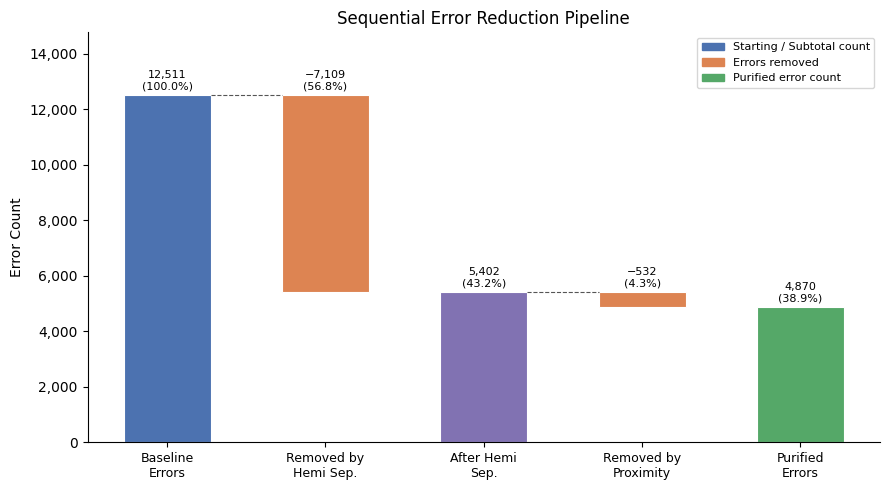

In [12]:
stages = [
    {"label": "Baseline\nErrors",        "value": n_errors,                  "type": "start"},
    {"label": "Removed by\nHemi Sep.",   "value": -(errors_removed),         "type": "neg"},
    {"label": "After Hemi\nSep.",        "value": combined_errors,           "type": "subtotal"},
    {"label": "Removed by\nProximity",   "value": -n_nearby,                 "type": "neg"},
    {"label": "Purified\nErrors",        "value": n_distal,                  "type": "end"},
]

colors = {"start": "#4C72B0", "neg": "#DD8452", "subtotal": "#8172B2", "end": "#55A868"}

# Compute running totals for bar bottoms
running = n_errors
bottoms, heights, bar_colors, xlabels, bar_vals = [], [], [], [], []

for s in stages:
    xlabels.append(s["label"])
    bar_colors.append(colors[s["type"]])
    if s["type"] in ("start", "subtotal", "end"):
        bottoms.append(0)
        heights.append(s["value"])
        bar_vals.append(s["value"])
    else:  # neg
        bottoms.append(running + s["value"])   # bottom of the negative bar
        heights.append(-s["value"])            # height = abs reduction
        bar_vals.append(s["value"])            # negative for label
        running += s["value"]

fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(stages))

bars = ax.bar(x_pos, heights, bottom=bottoms, color=bar_colors,
              edgecolor="white", linewidth=0.8, width=0.55)

# Connector lines between subtotals
connector_pairs = [(0,1),(2,3)]
prev_top = n_errors
for i, bar in enumerate(bars):
    top = bottoms[i] + heights[i]
    if i in [0, 2]:  # draw connector to next bar
        ax.plot([x_pos[i]+0.275, x_pos[i+1]-0.275], [top, top],
                color="#555", lw=0.8, ls="--")

# Annotations
pct_of_baseline = [n_errors, errors_removed, combined_errors, n_nearby, n_distal]
for i, (bar, val) in enumerate(zip(bars, bar_vals)):
    top  = bottoms[i] + heights[i]
    pct  = abs(val) / n_errors * 100
    sign = "" if val >= 0 else "−"
    ax.text(x_pos[i], top + 120,
            f"{sign}{abs(val):,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=8)

ax.set_xticks(x_pos)
ax.set_xticklabels(xlabels, fontsize=9)
ax.set_ylabel("Error Count", fontsize=10)
ax.set_title("Sequential Error Reduction Pipeline", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, n_errors * 1.18)
ax.spines[["top", "right"]].set_visible(False)

# Legend
legend_patches = [
    mpatches.Patch(color=colors["start"],    label="Starting / Subtotal count"),
    mpatches.Patch(color=colors["neg"],      label="Errors removed"),
    mpatches.Patch(color=colors["end"],      label="Purified error count"),
]
ax.legend(handles=legend_patches, fontsize=8, loc="upper right", framealpha=0.8)

plt.tight_layout()
plt.show()

✅ All values verified!
  Baseline → Hemisphere: 12511 → 5402 (removed 7,109)
  Hemisphere → Spatial:  5402 → 4870 (removed 532)
  Total reduction:       12511 → 4870 (removed 7,641, 61.1%)

Stage Summary:
1. Baseline    : 12,511 errors, 73.04% accuracy, 26.96% error rate
2. Hemisphere  : 5,402 errors, 88.36% accuracy, 11.64% error rate
3. Purified    : 4,870 errors, 89.50% accuracy, 10.50% error rate


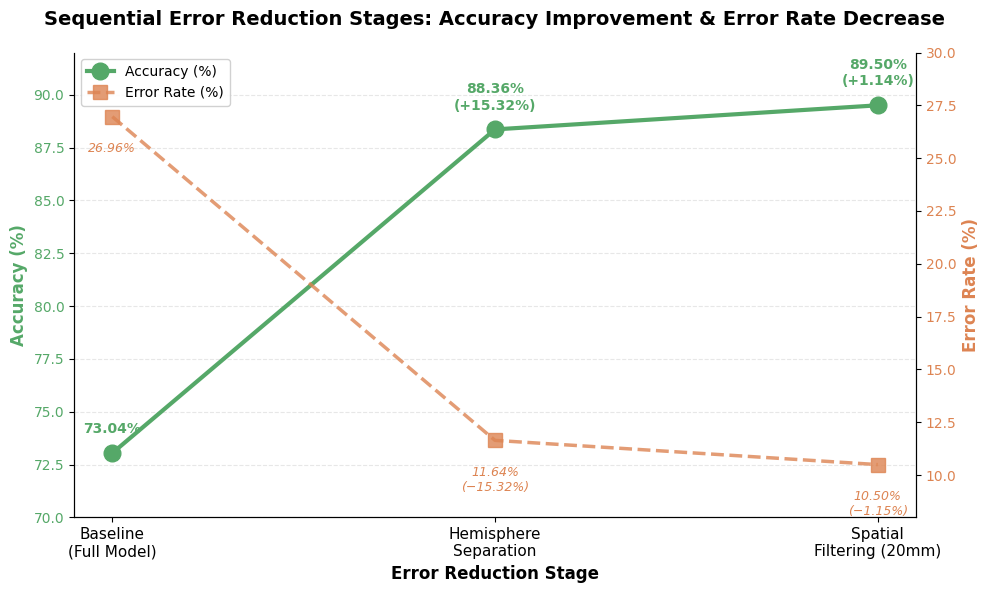


✓ Dual-axis accuracy plot saved to: figures/H3_accuracy_improvement_dual_axis.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ============================================================================
# VERIFIED DATA (from distance analysis)
# ============================================================================

# Baseline (Full Model - 232 regions)
n_errors = 12511          # Total baseline errors
baseline_accuracy = 73.04  # Task test accuracy

# After Hemisphere Separation
combined_errors = 5402     # Combined left + right hemisphere errors
hemisphere_accuracy = 88.36  # After hemisphere separation

# After Spatial Filtering (20mm threshold)
n_nearby = 532             # Errors removed (spatially proximate)
n_distal = 4870            # Purified errors (distal, ≥20mm)
spatial_accuracy = 89.50   # After spatial filtering

# Total samples
total_samples = 46400      # 200 subjects × 232 regions

# Verification
assert combined_errors == 5402, f"Hemisphere errors mismatch: {combined_errors}"
assert n_nearby + n_distal == combined_errors, f"Spatial split error: {n_nearby} + {n_distal} ≠ {combined_errors}"
assert n_distal == 4870, f"Distal errors mismatch: {n_distal}"

print("✅ All values verified!")
print(f"  Baseline → Hemisphere: {n_errors} → {combined_errors} (removed {n_errors - combined_errors:,})")
print(f"  Hemisphere → Spatial:  {combined_errors} → {n_distal} (removed {n_nearby})")
print(f"  Total reduction:       {n_errors} → {n_distal} (removed {n_errors - n_distal:,}, {(n_errors - n_distal)/n_errors*100:.1f}%)")

# ============================================================================
# Define stages with accuracy metrics
# ============================================================================

stages = [
    {
        "stage": "Baseline\n(Full Model)",
        "errors": n_errors,           # 12,511
        "total_samples": total_samples,
        "accuracy": baseline_accuracy,
        "error_rate": (n_errors / total_samples) * 100,  # 26.96%
        "label_short": "Baseline"
    },
    {
        "stage": "Hemisphere\nSeparation",
        "errors": combined_errors,    # 5,402
        "total_samples": total_samples,
        "accuracy": hemisphere_accuracy,
        "error_rate": (combined_errors / total_samples) * 100,  # 11.64%
        "label_short": "Hemisphere"
    },
    {
        "stage": "Spatial\nFiltering (20mm)",
        "errors": n_distal,           # 4,870
        "total_samples": total_samples,
        "accuracy": spatial_accuracy,
        "error_rate": (n_distal / total_samples) * 100,  # 10.50%
        "label_short": "Purified"
    }
]

# Extract data
stage_labels = [s["stage"] for s in stages]
accuracies = [s["accuracy"] for s in stages]
error_rates = [s["error_rate"] for s in stages]
error_counts = [s["errors"] for s in stages]

# Print summary
print("\nStage Summary:")
for i, s in enumerate(stages):
    print(f"{i+1}. {s['label_short']:12s}: {s['errors']:5,} errors, {s['accuracy']:5.2f}% accuracy, {s['error_rate']:5.2f}% error rate")

# ============================================================================
# PLOT: Dual-Axis Accuracy + Error Rate
# ============================================================================

fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Left axis: Accuracy
x_pos = np.arange(len(stages))
color_acc = "#55A868"  # Green
ax1.plot(x_pos, accuracies, marker='o', markersize=12, linewidth=3, 
         color=color_acc, label="Accuracy (%)", zorder=3)
ax1.set_xlabel("Error Reduction Stage", fontsize=12, fontweight='bold')
ax1.set_ylabel("Accuracy (%)", fontsize=12, fontweight='bold', color=color_acc)
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.set_ylim(70, 92)
ax1.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)

# Annotate accuracy values
for i, (x, acc) in enumerate(zip(x_pos, accuracies)):
    gain = "" if i == 0 else f"\n(+{acc - accuracies[i-1]:.2f}%)"
    ax1.text(x, acc + 0.8, f"{acc:.2f}%{gain}", 
             ha='center', va='bottom', fontsize=10, 
             color=color_acc, fontweight='bold')

# Right axis: Error Rate
ax2 = ax1.twinx()
color_err = "#DD8452"  # Orange
ax2.plot(x_pos, error_rates, marker='s', markersize=10, linewidth=2.5, 
         color=color_err, linestyle='--', label="Error Rate (%)", alpha=0.8, zorder=3)
ax2.set_ylabel("Error Rate (%)", fontsize=12, fontweight='bold', color=color_err)
ax2.tick_params(axis='y', labelcolor=color_err)
ax2.set_ylim(8, 30)

# Annotate error rate values
for i, (x, err) in enumerate(zip(x_pos, error_rates)):
    reduction = "" if i == 0 else f"\n(−{error_rates[i-1] - err:.2f}%)"
    ax2.text(x, err - 1.2, f"{err:.2f}%{reduction}", 
             ha='center', va='top', fontsize=9, 
             color=color_err, style='italic')

# X-axis
ax1.set_xticks(x_pos)
ax1.set_xticklabels(stage_labels, fontsize=11)

# Title
fig.suptitle("Sequential Error Reduction Stages: Accuracy Improvement & Error Rate Decrease", 
             fontsize=14, fontweight='bold', y=0.98)

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc='upper left', fontsize=10, framealpha=0.9)

# Clean up
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(fig_dir / "H3_accuracy_improvement_dual_axis.png", dpi=300, bbox_inches="tight")
plt.show()
print("\n✓ Dual-axis accuracy plot saved to:", fig_dir / "H3_accuracy_improvement_dual_axis.png")

## Cell 12 — Table 4: Sequential Pipeline Summary

In [14]:
acc_after_spatial = (N_SAMPLES - n_distal) / N_SAMPLES
cumulative_reduction = (1 - n_distal / n_errors) * 100

table4 = pd.DataFrame([
    {"Stage"             : "0 — Baseline (full connectivity)",
     "Errors Remaining" : n_errors,
     "Accuracy"         : f"{baseline_acc*100:.2f}%",
     "Cumulative Reduction": "0.0%"},
    {"Stage"             : "1 — After hemisphere separation",
     "Errors Remaining" : combined_errors,
     "Accuracy"         : f"{combined_acc*100:.2f}%",
     "Cumulative Reduction": f"{errors_removed/n_errors*100:.1f}%"},
    {"Stage"             : "2 — After spatial proximity filter (<20mm)",
     "Errors Remaining" : n_distal,
     "Accuracy"         : f"{acc_after_spatial*100:.2f}%",
     "Cumulative Reduction": f"{cumulative_reduction:.1f}%"},
]).set_index("Stage")

table4

,Errors Remaining,Accuracy,Cumulative Reduction
Stage,,,
0 — Baseline (full connectivity),12511,73.04%,0.0%
1 — After hemisphere separation,5402,88.36%,56.8%
2 — After spatial proximity filter (<20mm),4870,89.50%,61.1%


## Cell 13 — McNemar's Test: Baseline vs Combined Hemisphere-Specific

In [15]:
# McNemar's test requires paired predictions on the SAME samples
# baseline: task_pred (full model on all 232 regions)
# combined: combined_pred (left model on left + right model on right)
# Both must cover the same samples in the same order.
# Check lengths match; if not, use the intersection.

n_base   = len(task_true)
n_comb   = len(combined_true)
n_paired = min(n_base, n_comb)

base_correct = (task_pred[:n_paired]     == task_true[:n_paired])
comb_correct = (combined_pred[:n_paired] == combined_true[:n_paired])

# Contingency table
# b = baseline correct, combined wrong
# c = baseline wrong,   combined correct
b = int(( base_correct & ~comb_correct).sum())
c = int((~base_correct &  comb_correct).sum())

# McNemar chi-square with continuity correction
mcnemar_chi2 = (abs(b - c) - 1)**2 / (b + c)
mcnemar_p    = stats.chi2.sf(mcnemar_chi2, df=1)
odds_ratio   = c / b if b > 0 else float("inf")

print(f"McNemar's test (baseline vs combined hemisphere-specific)")
print(f"  n paired samples  : {n_paired:,}")
print(f"  b (base✓, comb✗) : {b:,}")
print(f"  c (base✗, comb✓) : {c:,}")
print(f"  χ²               : {mcnemar_chi2:.1f}")
print(f"  p-value          : {mcnemar_p:.2e}")
print(f"  Odds ratio (c/b) : {odds_ratio:.2f}")

McNemar's test (baseline vs combined hemisphere-specific)
  n paired samples  : 46,400
  b (base✓, comb✗) : 3,745
  c (base✗, comb✓) : 10,854
  χ²               : 3460.8
  p-value          : 0.00e+00
  Odds ratio (c/b) : 2.90


## Cell 14 — Key Finding Summary

In [16]:
print("=" * 68)
print("KEY FINDING — H3: Systematic Error Decomposition")
print("=" * 68)
print()
print(f"  Baseline: {n_errors:,} errors ({(1-baseline_acc)*100:.2f}% error rate)")
print()
print(f"  Error structure is non-random  χ²(3) = {chi2_stat:.1f}, p = {chi2_p:.2e}")
print(f"  Cramér's V = {cramers_v:.3f}")
print(f"  Cross-hemisphere errors: {cross_hemi_total:,} ({cross_hemi_total/n_errors*100:.1f}%)")
print(f"  Dominant error type (Same Hemi, Diff Net): {SH_DN:,} ({SH_DN/n_errors*100:.1f}%)")
print()
print(f"  Stage 1 — Hemisphere separation:")
print(f"    Combined accuracy: {combined_acc*100:.2f}%  (+{acc_gain*100:.2f}% vs baseline)")
print(f"    Errors removed:    {errors_removed:,}  ({errors_removed/n_errors*100:.1f}% of baseline)")
print(f"    McNemar: χ² = {mcnemar_chi2:.1f}, p = {mcnemar_p:.2e}, OR = {odds_ratio:.2f}")
print()
print(f"  Stage 2 — Spatial proximity filter (<{PROXIMITY_THRESHOLD_MM} mm):")
print(f"    Nearby errors removed: {n_nearby:,} ({n_nearby/combined_errors*100:.2f}% of hemi errors)")
print()
print(f"  → H3 CONFIRMED: {n_distal:,} distal within-hemisphere errors represent")
print(f"    the purified functional reorganization signal.")
print("=" * 68)

KEY FINDING — H3: Systematic Error Decomposition

  Baseline: 12,511 errors (26.96% error rate)

  Error structure is non-random  χ²(3) = 73162.2, p = 0.00e+00
  Cramér's V = 1.396
  Cross-hemisphere errors: 5,454 (43.6%)
  Dominant error type (Same Hemi, Diff Net): 3,585 (28.7%)

  Stage 1 — Hemisphere separation:
    Combined accuracy: 88.36%  (+15.32% vs baseline)
    Errors removed:    7,109  (56.8% of baseline)
    McNemar: χ² = 3460.8, p = 0.00e+00, OR = 2.90

  Stage 2 — Spatial proximity filter (<20 mm):
    Nearby errors removed: 532 (9.85% of hemi errors)

  → H3 CONFIRMED: 4,870 distal within-hemisphere errors represent
    the purified functional reorganization signal.


In [17]:
# Save the files so that i can use them in next steps where i will work on purified errors only (stage 3)
np.save(LEFT_TASK_DIR  / "purified_true_labels.npy", left_true[left_error_mask][~left_nearby_mask])
np.save(LEFT_TASK_DIR  / "purified_predictions.npy", left_pred[left_error_mask][~left_nearby_mask])
np.save(RIGHT_TASK_DIR / "purified_true_labels.npy", right_true[right_error_mask][~right_nearby_mask])
np.save(RIGHT_TASK_DIR / "purified_predictions.npy", right_pred[right_error_mask][~right_nearby_mask])
print("\n✓ Purified error labels and predictions saved for next steps.")


✓ Purified error labels and predictions saved for next steps.
